## Notebook 6: AC Adaptation

In [1]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [2]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio

# from earlier notebooks (city-agnostic via config)
tmpl_path = INT / "template_ref.tif"   # reference WBGT grid (same as NB5)
mask_tif  = INT / "city_mask.tif"      # boolean mask on that grid
fua_gpkg  = Path(paths.get("fua_gpkg", OUT / f"{SLUG}_fua.gpkg"))

# loading ref grid + mask
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# loading FUA
assert fua_gpkg.exists(), f"Missing {fua_gpkg} (re-run NB2)."
fua = gpd.read_file(fua_gpkg, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

print("WBGT grid:", (HGT, WDT), "| CRS:", ref_meta["crs"])
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))
print("FUA features:", len(fua))

# population files
age_npz = INT / "age_on_ref.npz"
pop_npz = INT / "pop_on_ref.npz"
assert pop_npz.exists() and age_npz.exists(), "Missing age/pop arrays."

pop_on_ref = np.load(pop_npz)["pop"].astype(float)

agez = np.load(age_npz)
age_on_ref = {
    "<15":    agez["lt15"].astype(float),
    "15-64":  agez["a15_64"].astype(float),
    "65+":    agez["g65"].astype(float),
}

assert pop_on_ref.shape == (ref_meta["height"], ref_meta["width"])
print("pop_on_ref loaded. Total pop:", float(np.nansum(pop_on_ref)))

WBGT grid: (266, 353) | CRS: EPSG:4326
CITY_MASK true pixels: 76050
FUA features: 1
pop_on_ref loaded. Total pop: 2550385.60649897


In [4]:
import geopandas as gpd, rasterio as rio, pandas as pd, numpy as np

# paths
gpkg_path = OUT / f"{SLUG}_regions.gpkg"
tif_path  = OUT / f"{SLUG}_muni_on_ref.tif"
lut_path  = OUT / f"{SLUG}_muni_lut.csv"

# loading vectors
regions = gpd.read_file(gpkg_path, layer="regions").to_crs("EPSG:4326")
muni    = gpd.read_file(gpkg_path, layer="muni").to_crs("EPSG:4326")
lut     = pd.read_csv(lut_path)

# loading label grid (aligned to WBGT ref grid)
with rio.open(tif_path) as src:
    assert src.crs == ref_meta["crs"] and src.transform == ref_meta["transform"], "Grid mismatch."
    muni_on_ref = src.read(1).astype("int32")

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)

valid_ids = np.unique(muni_on_ref[muni_on_ref > 0])
print("Unique muni IDs (excluding 0):", len(valid_ids))

Loaded regions: 16 polygons; muni_on_ref shape: (266, 353)
Unique muni IDs (excluding 0): 15


In [5]:
# loading hazard and exposure saved in NB2 

from pathlib import Path
import numpy as np
import rasterio as rio

def _pick_existing(cands, what):
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    tried = "\n".join(str(Path(p)) for p in cands if p)
    raise FileNotFoundError(f"Missing {what}. Tried:\n{tried}\n→ Re-run NB2/NB3 for {SLUG} or update `paths`.")

# ref grid shape
with rio.open(tmpl_path) as src:
    HGT, WDT = src.height, src.width

haz_candidates = [
    paths.get("hazard_h5"),
    INT / f"hazard_HEAT_{SLUG}.h5",  # NB3 save
    INT / f"{SLUG}_hazard_HEAT.h5",
    INT / "hazard_HEAT.h5",
    OUT / f"hazard_HEAT_{SLUG}.h5",
    OUT / f"{SLUG}_hazard_HEAT.h5",
]

exp_candidates = [
    paths.get("exposure_h5"),
    INT / f"exposure_people_{SLUG}.h5",  # NB3 save
    INT / f"{SLUG}_exposure_people.h5",
    INT / "exposure_people.h5",
    OUT / f"exposure_people_{SLUG}.h5",
    OUT / f"{SLUG}_exposure_people.h5",
]

haz_path = _pick_existing(haz_candidates, "hazard .h5")
exp_path = _pick_existing(exp_candidates, "exposure .h5")

# CLIMADA 
try:
    from climada.hazard import Hazard
except Exception:
    from climada.hazard.base import Hazard
try:
    from climada.entity import Exposures
except Exception:
    from climada.entity.exposures.base import Exposures

try:
    H = Hazard.from_hdf5(haz_path)
except Exception:
    H = Hazard(); H.read_hdf5(haz_path)

try:
    exp = Exposures.from_hdf5(exp_path)
except Exception:
    exp = Exposures(); exp.read_hdf5(exp_path)

# minimal metadata defaults
n_ev = len(H.event_id)
if not getattr(H, "haz_type", None): H.haz_type = "HEAT"
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != n_ev:
    H.event_name = np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)
if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    H.date = np.array([np.datetime64(f"{int(y)}-07-01") for y in H.event_id])
if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = np.ones(n_ev, dtype=float)
if not getattr(H, "frequency_unit", None): H.frequency_unit = "1/year"

# strict grid check
n_cells = H.intensity.shape[-1]
assert n_cells == HGT * WDT, (
    f"[{SLUG}] grid mismatch: hazard cells={n_cells} vs ref={HGT*WDT}. Rebuild hazard on this ref grid."
)

print(f"Using hazard:   {haz_path}")
print(f"Using exposure: {exp_path}")
print("Loaded H events:", n_ev, "| cells:", n_cells)
print("Loaded exp total pop:", float(getattr(exp.gdf, "value", np.array([])).sum()))

def _row_to_grid(mat, irow, shape=(HGT, WDT)):
    row = mat[irow, :]
    if hasattr(row, "toarray"):
        row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

Using hazard:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/hazard_HEAT_rome.h5
Using exposure: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/exposure_people_rome.h5
Loaded H events: 5 | cells: 93898
Loaded exp total pop: 2550385.6069542365


In [6]:
# age-specific impact functions "frozen" in NB4 
import json, numpy as np
from pathlib import Path

def _pick_existing(cands, what):
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    tried = "\n".join(str(Path(p)) for p in cands if p)
    raise FileNotFoundError(f"Missing {what}. Tried:\n{tried}")

froze_candidates = [
    paths.get("if_freeze_json") if "paths" in globals() else None,
    Path(INT) / f"if_curves_frozen_{SLUG}.json",  # preferred
    Path(INT) / "if_curves_frozen.json",         
    Path(OUT) / f"if_curves_frozen_{SLUG}.json", 
]
froze_path = _pick_existing(froze_candidates, "frozen impact-function JSON")

with open(froze_path, "r") as fh:
    IF_FREEZE = json.load(fh)

class _IF:
    def __init__(self, intensity, mdd, name=None, fid=None):
        self.intensity = np.asarray(intensity, float)
        self.mdd       = np.asarray(mdd, float)
        self.name      = name
        self.id        = fid

required = {"intensity", "mdd"}
for k, v in IF_FREEZE.items():
    missing = required - v.keys()
    if missing:
        raise ValueError(f"IF '{k}' missing fields: {missing}")

age_ifs = {
    k: _IF(v["intensity"], v["mdd"], name=v.get("name"), fid=v.get("id"))
    for k, v in IF_FREEZE.items()
}
print("Loaded frozen IFs:",
      {k: (age_ifs[k].name, len(age_ifs[k].intensity)) for k in age_ifs})

Loaded frozen IFs: {'<15': ('Heat mortality · <15', 128), '15-64': ('Heat mortality · 15-64', 128), '65+': ('Heat mortality · 65+', 128)}


In [7]:
# age rasters on the reference grid (saved in NB2) 
import numpy as np
from pathlib import Path

# prefer city-tagged
_age_tagged = INT / f"age_on_ref_{SLUG}.npz"
age_npz = _age_tagged if _age_tagged.exists() else (INT / "age_on_ref.npz")

agez = np.load(age_npz)
age_on_ref = {
    "<15":   agez["lt15"].astype("float32"),
    "15-64": agez["a15_64"].astype("float32"),
    "65+":   agez["g65"].astype("float32"),
}

## Current AC Penetration at the CAP Level

**Loading data : income and AC penetration**

In [8]:
files = cfg.get("files", {})

ac_conf = cfg.get("ac", {})
ac_penetration = P(ac_conf.get("penetration_file", ""))
ac_kwh         = P(ac_conf.get("gridded_file", ""))  # if needed later
ssp_choice     = float(ac_conf.get("ssp", 2))
year_choice    = int(ac_conf.get("year", 2050))

for p in [ac_penetration]:
    assert p and p.exists(), f"Missing AC file from YAML: {p}"

# city label 
CITY_LABEL = cfg.get("city_name", SLUG.title())

In [9]:
import xarray as xr

ds = xr.open_dataset(ac_penetration, decode_times=False)

def pick_one(seq, options):
    for name in options:
        if name in seq: return name
    low = {s.lower(): s for s in seq}
    for name in options:
        if name.lower() in low: return low[name.lower()]
    return None

# prefer coords 
namespace = set(list(ds.dims) + list(ds.coords))
DIM_LAT  = pick_one(namespace, ["lat","latitude","y"])
DIM_LON  = pick_one(namespace, ["lon","longitude","x"])
DIM_SSP  = pick_one(namespace, ["ssp","SSP","scenario"])
DIM_TIME = pick_one(namespace, ["time","Time","year","Year"])

def pick_var(ds):
    yaml_var = ac_conf.get("var_name")
    if yaml_var and yaml_var in ds.data_vars:
        return yaml_var
    keys = ["ac", "penetration", "ownership", "share", "cool"]
    for v in ds.data_vars:
        name = v.lower()
        attrs = " ".join([f"{k} {str(ds[v].attrs[k]).lower()}" for k in ds[v].attrs])
        if any(k in (name + " " + attrs) for k in keys):
            return v
    return list(ds.data_vars)[0]

VAR = pick_var(ds)
print(f"Using variable: {VAR}")

# decode years 
def decode_years(tvals, units: str | None):
    tvals = np.asarray(tvals, dtype=float)
    if np.all((tvals >= 1800) & (tvals <= 2600)):  # already years
        return tvals.astype(int)
    units = (units or "").lower()
    m = re.search(r"years\s+since\s+(\d{4})", units)
    if m:
        return (int(m.group(1)) + tvals).astype(int)
    return tvals.astype(int)

if DIM_TIME:
    years_raw = np.asarray(ds[DIM_TIME].values)
    years = decode_years(years_raw, getattr(ds[DIM_TIME], "attrs", {}).get("units"))
else:
    years = None

# pick the city pixel via FUA centroid 
geom_4326 = fua.to_crs("EPSG:4326").geometry
try:
    centroid = geom_4326.union_all().centroid
except AttributeError:
    centroid = geom_4326.unary_union.centroid
lat0, lon0 = float(centroid.y), float(centroid.x)

# building the .sel() dict with the discovered coord names
sel = {}
if DIM_SSP:  sel[DIM_SSP]  = ssp_choice
if DIM_TIME: sel[DIM_TIME] = year_choice
if DIM_LAT:  sel[DIM_LAT]  = lat0
if DIM_LON:  sel[DIM_LON]  = lon0

ac_city_da = ds[VAR].sel(sel, method="nearest")
ac_city = float(ac_city_da.values)
if ac_city > 1.5:  # convert 0–100 to 0–1
    ac_city /= 100.0

# report what we actually sampled
lat_used = float(ac_city_da.coords[DIM_LAT].values) if DIM_LAT else lat0
lon_used = float(ac_city_da.coords[DIM_LON].values) if DIM_LON else lon0
print(f"{CITY_LABEL} AC (SSP{int(ssp_choice)}, {year_choice}) from pixel "
      f"({lat_used:.3f}, {lon_used:.3f}) = {ac_city:.3f}")

# uniform baseline coverage on this city's grid 
coverage_base = np.full(ref_data.shape, np.nan, dtype="float32")
coverage_base[CITY_MASK] = ac_city

Using variable: ac_penetration
Rome AC (SSP2, 2050) from pixel (41.750, 12.750) = 0.724


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Under the scenario SSP2, 2050, for the Rome pixel (41.750, 12.750), the AC penetration share is of 0.724. 
</blockquote>

> **Explanation of the following steps:**
> - We only know the Rome AC penetration share
> - We have income data at the CAP level
    > - We want a map across CAP where:
    > - Higher AC in richer CAPS and lower in poorer caps
    > - stays in plausible bounds
    > - averages back to 0.724 when we weight by ppl 

**Income Dataset**

In [10]:
import re
from pathlib import Path

files = cfg.get("files", {})
rel = files["income_csv"]                         
rel = re.sub(r'(^|/)[Ii]ncome/', r'\1income/', rel)  

income_csv = P(rel)                              
assert Path(income_csv).exists(), f"Missing income CSV: {income_csv}"
print("Income CSV →", income_csv)

Income CSV → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/income/Redditi_e_principali_variabili_IRPEF_su_base_subcom.csv


In [11]:
# normalising a CAP to a 5-digit string with 00 before or na if missing or invalid
def to_cap5(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\D","", s)
    return np.nan if not s else s.zfill(5)[-5:]

def _norm(s):
    return str(s).upper()

In [12]:
# columns for the Italian IRPEF file (same for Rome/Genova) 
COL_CITY   = "Denominazione Comune"
COL_CAP    = "CAP"
COL_TAXP   = "Numero contribuenti"
COL_TOTINC = "Reddito complessivo - Ammontare in euro"

In [13]:
# aliases from YAML 
aliases = [_norm(cfg.get("city_name", SLUG))]
aliases += [_norm(a) for a in cfg.get("cooling_city_aliases", [])]
aliases = list(dict.fromkeys(aliases))  

In [14]:
# load and city-filter
df = pd.read_csv(income_csv, sep=None, engine="python")
city_col = df[COL_CITY].astype(str).map(_norm)
mask = pd.Series(False, index=df.index)
for a in aliases:
    mask |= city_col.str.contains(a, na=False)

inc_city = df[mask].copy()

In [15]:
import re

# clean and compute 
inc_city[COL_TAXP]   = pd.to_numeric(inc_city[COL_TAXP],   errors="coerce")
inc_city[COL_TOTINC] = pd.to_numeric(inc_city[COL_TOTINC], errors="coerce")
inc_city["cap5"]     = inc_city[COL_CAP].map(to_cap5)

inc_city = inc_city.dropna(subset=["cap5", COL_TAXP, COL_TOTINC])
inc_city = inc_city[inc_city[COL_TAXP] > 0].copy()

inc_city["inc_mean"] = inc_city[COL_TOTINC] / inc_city[COL_TAXP]
lo, hi = inc_city["inc_mean"].quantile([0.01, 0.99])
inc_city["inc_w"] = inc_city["inc_mean"].clip(lo, hi)

print(f"[{SLUG}] CAP rows: {len(inc_city)} | unique CAP: {inc_city['cap5'].nunique()}")
print(f"[{SLUG}] Taxpayers total: {int(inc_city[COL_TAXP].sum())}")
city_mean = inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum()
print(f"[{SLUG}] City per-taxpayer mean (EUR): {city_mean:,.0f}")

[rome] CAP rows: 72 | unique CAP: 72
[rome] Taxpayers total: 1951864
[rome] City per-taxpayer mean (EUR): 30,702


Nice : one row per CAP, no duplicate + 30,000 eur per taxpayer mean is plausible

**CAP polygons to CLIMADA grid**

In [16]:
files = cfg.get("files", {})
p_cap_shp = P(files.get("cap_shp", "CAPZONE/CAPZONE.shp"))
assert p_cap_shp.exists(), f"Missing CAP shapefile: {p_cap_shp}"

In [17]:
# CAP polygons to CLIMADA grid labels
import numpy as np
import geopandas as gpd
from shapely import set_precision
from rasterio.features import rasterize

def pick_col(cols, *cands):
    low = {c.lower(): c for c in cols}
    for cand in cands:
        for k, v in low.items():
            if cand.lower() in k:
                return v
    raise KeyError(f"None of {cands} found in columns: {list(cols)}")

# loading CAP shapes
cap = gpd.read_file(p_cap_shp)
cap = cap.set_crs("EPSG:4326", allow_override=True) if cap.crs is None else cap.to_crs("EPSG:4326")

cap_col = pick_col(
    cap.columns,
    "cap", "CAP", "codice", "cod_cap", "cap_5", "cap5", "zip", "postal", "postcode"
)
cap["cap5"] = cap[cap_col].map(to_cap5)
cap = cap[cap["cap5"].notna()].copy()

# fix geometries and precision
cap = cap.set_geometry(cap.geometry.buffer(0))
cap = cap[~cap.geometry.is_empty]
cap = cap.set_geometry(set_precision(cap.geometry, grid_size=1e-9))

cap_4326 = (cap[["cap5","geometry"]]
            .dissolve(by="cap5", as_index=False))

# clipping to FUA 
fua_4326 = fua.to_crs("EPSG:4326")[["geometry"]]
cap_4326 = gpd.overlay(cap_4326, fua_4326, how="intersection")
cap_4326 = cap_4326[~cap_4326.geometry.is_empty].reset_index(drop=True)

# stable IDs + project to ref grid CRS 
cap_4326["cap_id"] = np.arange(1, len(cap_4326)+1, dtype=int)
cap_ref = cap_4326.to_crs(ref_meta["crs"])

# rasterize to the ref grid 
shapes = [(geom, int(cid)) for geom, cid in zip(cap_ref.geometry, cap_ref["cap_id"])]
cap_on_ref = rasterize(
    shapes=shapes,
    out_shape=ref_data.shape,
    transform=ref_meta["transform"],
    fill=0, dtype="int32",
    all_touched=False
)

# checks 
haz_mask = np.isfinite(ref_data)
u_ids = np.unique(cap_on_ref[haz_mask])
print(f"[{SLUG}] CAP pixels in hazard: {int(((cap_on_ref>0)&haz_mask).sum()):,}")
print(f"[{SLUG}] Unique CAP IDs on grid: {u_ids[u_ids>0].size} / {len(cap_ref)}")

# lookups for later 
cap_id_to_cap5 = dict(zip(cap_ref["cap_id"].astype(int), cap_ref["cap5"]))
cap5_to_id     = {v:k for k,v in cap_id_to_cap5.items()}
cap_lut        = {str(row.cap5): int(row.cap_id) for _, row in cap_ref.iterrows()}

[rome] CAP pixels in hazard: 76,050
[rome] Unique CAP IDs on grid: 81 / 118


- WBGT hazard footprint: 81 of 118 CAP zones
- 86,430 hazard pixels labeled by CAP

In [18]:
# new mask
CAP_PIX   = CITY_MASK & (cap_on_ref  > 0) # pixels labeled by CAP

In [19]:
# Only the income table from CSV (no population here)
inc_agg = (inc_city.groupby("cap5", as_index=False)
           .agg(taxp=(COL_TAXP, "sum"),
                inc_sum=(COL_TOTINC, "sum")))
inc_agg["inc_mean"] = inc_agg["inc_sum"] / inc_agg["taxp"]

canon = cap_ref[["cap_id","cap5"]].drop_duplicates().copy()
canon["cap5"] = canon["cap5"].astype(str).str.strip().str.zfill(5)

df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":    pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]
cap_pop_grid = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop": "pop_cap"}))

cap_stats = (canon
    .merge(cap_pop_grid, on="cap_id", how="left")
    .merge(inc_agg[["cap5","taxp","inc_sum","inc_mean"]], on="cap5", how="left")
    .fillna({"pop_cap": 0.0})
)

# impute inc_mean where we have population but missing CSV entry
city_mean_inc = float(inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum())
need_inc = (cap_stats["pop_cap"] > 0) & (~cap_stats["inc_mean"].notna())
cap_stats.loc[need_inc, "inc_mean"] = city_mean_inc

In [20]:
# pop-weighted percentile rank of CAP income 
def weighted_percentile_rank(values, weights):
    # sorting by values (ascending: poorer first)
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights, dtype=float)[order]
    if w.sum() <= 0:
        return np.full_like(v, 0.5, dtype=float)
    # midpoint cumulative share: places each observation at the center of its mass
    c = np.cumsum(w) - 0.5*w
    p = c / w.sum()
    out = np.empty_like(p, dtype=float)
    out[order] = p
    return out
# function returns 0-1 rank for each value using weights as population
# mass: Lower income -> lower rank (poorer), 'midpoint' convention so identical values land around their weighted middle. If total weight <= 0, return 0.5 for all 

In [21]:
nz = cap_stats["pop_cap"] > 0
if nz.sum() >= 10:
    lo, hi = cap_stats.loc[nz, "inc_mean"].quantile([0.01, 0.99])
else:
    lo, hi = cap_stats["inc_mean"].min(), cap_stats["inc_mean"].max()
cap_stats["inc_rank_base"] = cap_stats["inc_mean"].clip(lo, hi)

# ranking poorer to richer in [0,1], weighted by pop (WorldPop)
# Pop-weighted percentile rank (poorer : lower rank), using grid pop as weights
mask = nz & np.isfinite(cap_stats["inc_rank_base"])
p = np.full(len(cap_stats), np.nan, float)
p[mask] = weighted_percentile_rank(
    cap_stats.loc[mask, "inc_rank_base"].to_numpy(),
    cap_stats.loc[mask, "pop_cap"].to_numpy()
)
cap_stats["p_inc"] = np.clip(p, 1e-3, 1-1e-3)

# QA
grid_pop = float(np.nansum(pop_on_ref[CAP_PIX]))
stats_pop = float(cap_stats["pop_cap"].sum())
print(f"[{SLUG}] QA Sum(pop_cap)/grid_pop = {stats_pop/grid_pop:.6f}")

[rome] QA Sum(pop_cap)/grid_pop = 1.000000


In [22]:
# using citywide AC share sampled earlier from the NetCDF (ac_city) 
ac_city = float(ac_city)
# normalising in case dataset was 0–100
if ac_city > 1.0:
    ac_city /= 100.0
ac_city = float(np.clip(ac_city, 0.0, 1.0))

# valid rows for calibration: have population and finite p_inc 
valid = (cap_stats["pop_cap"] > 0) & np.isfinite(cap_stats["p_inc"])
if not valid.any():
    raise RuntimeError("No valid CAP rows (require pop_cap>0 and finite p_inc).")

p_inc = cap_stats.loc[valid, "p_inc"].to_numpy(dtype=float)
w     = cap_stats.loc[valid, "pop_cap"].to_numpy(dtype=float)

# logistic map params 
ac_cfg = cfg.get("ac", {})
ac_min = float(ac_cfg.get("ac_min", 0.05))
ac_max = float(ac_cfg.get("ac_max", 0.98))
s      = float(ac_cfg.get("rank_slope", 2.2))

# logistic(rank) in [ac_min, ac_max]
sig    = 1.0 / (1.0 + np.exp(-s * (p_inc - 0.5)))
ac_raw = ac_min + (ac_max - ac_min) * sig  

def avg_after_clip(k: float) -> float:
    x = np.clip(ac_min + k * (ac_raw - ac_min), ac_min, ac_max)
    return float(np.average(x, weights=w)) if w.sum() > 0 else float(x.mean())

# feasibility
lo_mean, hi_mean = avg_after_clip(0.0), avg_after_clip(1e6)
if not (lo_mean - 1e-9 <= ac_city <= hi_mean + 1e-9):
    print(f"[warn] target {ac_city:.3f} outside [{lo_mean:.3f}, {hi_mean:.3f}] "
          f"given ac_min/ac_max; consider adjusting YAML.")

# bisection to hit pop-weighted mean = ac_city 
k_lo, k_hi = 0.0, 1e6
for _ in range(60):
    k_mid = 0.5 * (k_lo + k_hi)
    if avg_after_clip(k_mid) < ac_city:
        k_lo = k_mid
    else:
        k_hi = k_mid
k_star = 0.5 * (k_lo + k_hi)

# write back to full table 
ac_cap_baseline = np.full(len(cap_stats), np.nan, dtype=float)
ac_cap_baseline[valid.values] = np.clip(
    ac_min + k_star * (ac_raw - ac_min), ac_min, ac_max
)
cap_stats["ac_cap_baseline"] = ac_cap_baseline

achieved = float(np.average(ac_cap_baseline[valid], weights=w))
print(f"[{CITY_LABEL}] AC by CAP → target mean={ac_city:.3f}, achieved={achieved:.3f}, k*={k_star:.4g} "
      f"(valid CAPs={valid.sum()}/{len(valid)})")

[Rome] AC by CAP → target mean=0.724, achieved=0.724, k*=1.464 (valid CAPs=81/118)


In [23]:
# keeping only CAPs with population on the CLIMADA grid
cap_sub = cap_stats.loc[
    (cap_stats["pop_cap"] > 0)
    & np.isfinite(cap_stats["inc_mean"])
    & np.isfinite(cap_stats["ac_cap_baseline"]),
    ["cap5", "inc_mean", "inc_rank_base", "p_inc", "ac_cap_baseline", "pop_cap"]
].copy()

pd.options.display.float_format = "{:,.3f}".format

n_show = min(8, len(cap_sub))

# poorest / richest (using inc_rank_base for ordering, showing also inc_mean)
print("Poorest CAPs (by clipped income rank): expect low p_inc & low AC baseline")
display(cap_sub.sort_values("inc_rank_base", kind="mergesort").head(n_show))

print("\nRichest CAPs (by clipped income rank): expect high p_inc & high AC baseline")
display(cap_sub.sort_values("inc_rank_base", ascending=False, kind="mergesort").head(n_show))

Poorest CAPs (by clipped income rank): expect low p_inc & low AC baseline


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_baseline,pop_cap
40,00119,"16,405.440","19,472.391",0.003,0.392,"17,485.161"
52,00133,"20,239.128","20,239.128",0.027,0.405,"104,346.731"
51,00132,"20,526.122","20,526.122",0.050,0.418,"9,058.825"
87,00172,"21,838.697","21,838.697",0.058,0.424,"35,387.854"
47,00126,"21,879.120","21,879.120",0.073,0.432,"37,270.786"
86,00171,"21,986.438","21,986.438",0.084,0.439,"21,520.389"
85,00169,"22,324.881","22,324.881",0.095,0.446,"34,904.343"
102,00188,"22,460.978","22,460.978",0.104,0.452,"11,031.125"



Richest CAPs (by clipped income rank): expect high p_inc & high AC baseline


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_baseline,pop_cap
109,00197,"73,978.616","70,013.808",0.994,0.980,"28,650.379"
101,00187,"69,022.606","69,022.606",0.985,0.980,"20,945.950"
110,00198,"62,380.569","62,380.569",0.975,0.980,"27,986.802"
100,00186,"59,432.594","59,432.594",0.965,0.980,"24,992.352"
106,00193,"57,444.654","57,444.654",0.958,0.980,"9,688.623"
77,00161,"51,451.279","51,451.279",0.952,0.980,"21,326.934"
98,00184,"51,072.271","51,072.271",0.943,0.980,"24,342.991"
104,00191,"50,621.539","50,621.539",0.933,0.980,"24,873.101"


In [24]:
# correlation (simple Pearson on CAP means, weighted version below)
print("\nUnweighted Pearson corr:")
display(cap_sub[["inc_mean", "ac_cap_baseline"]].corr().round(3))


Unweighted Pearson corr:


,inc_mean,ac_cap_baseline
inc_mean,1.000,0.824
ac_cap_baseline,0.824,1.000


In [25]:
# weighted Pearson using grid population
def weighted_corr(x, y, w):
    x = np.asarray(x, float); y = np.asarray(y, float); w = np.asarray(w, float)
    m_x = np.average(x, weights=w); m_y = np.average(y, weights=w)
    cov = np.average((x - m_x) * (y - m_y), weights=w)
    sx = np.sqrt(np.average((x - m_x)**2, weights=w))
    sy = np.sqrt(np.average((y - m_y)**2, weights=w))
    return cov / (sx * sy) if (sx > 0 and sy > 0) else np.nan

print(f"Weighted Pearson corr (by grid pop): {weighted_corr(cap_sub['inc_mean'], cap_sub['ac_cap_baseline'], cap_sub['pop_cap']):.3f}")

Weighted Pearson corr (by grid pop): 0.833


In [26]:
mean_pop = np.average(cap_sub["ac_cap_baseline"], weights=cap_sub["pop_cap"])
print(f"\nPop-weighted mean = {mean_pop:.3f}")


Pop-weighted mean = 0.724


Text(0.5, 1.0, 'AC baseline vs income (dot size = CAP grid population)')

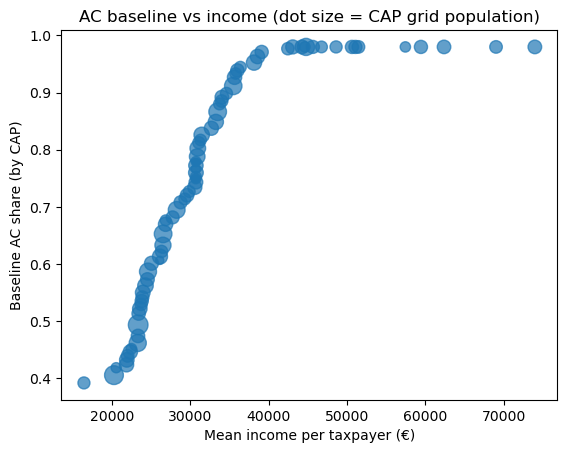

In [27]:
size = 200 * np.sqrt(cap_sub["pop_cap"] / cap_sub["pop_cap"].max())
size = np.clip(size, 10, None)

ax = cap_sub.plot.scatter(x="inc_mean", y="ac_cap_baseline", s=size, alpha=0.7)
ax.set_xlabel("Mean income per taxpayer (€)")
ax.set_ylabel("Baseline AC share (by CAP)")
ax.set_title("AC baseline vs income (dot size = CAP grid population)")

**Current CAP AC Coverage on CLIMADA GRID**

Pop coverage by CAP raster: 100.00%
[QA] City pop-w mean on grid: 0.724 (target 0.724)
[QA] City pop-w mean from CAP agg: 0.724 (target 0.724)
[QA] City pop-w mean (CITY_MASK): 0.724 (target 0.724)


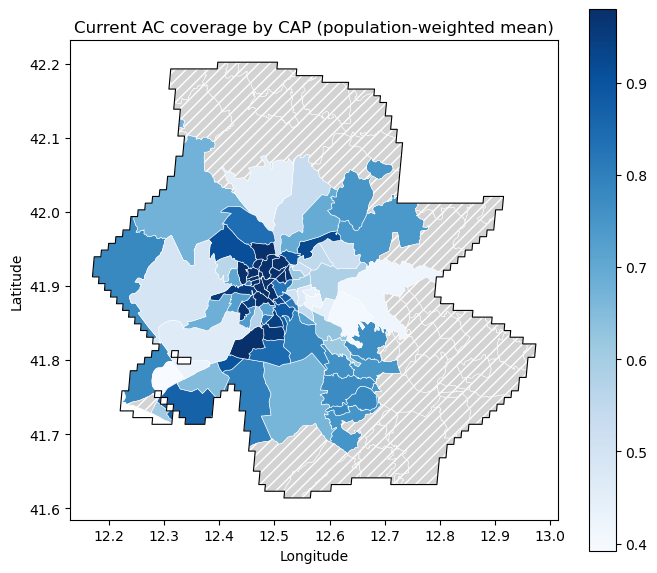


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.392,"17,485.161",39.185
1,53,00133,0.405,"104,346.731",40.548
2,52,00132,0.418,"9,058.825",41.848
3,88,00172,0.424,"35,387.854",42.365
4,48,00126,0.432,"37,270.786",43.220
5,87,00171,0.439,"21,520.389",43.921
6,86,00169,0.446,"34,904.343",44.601
7,103,00188,0.452,"11,031.125",45.160
8,67,00148,0.462,"71,563.741",46.176
9,93,00177,0.474,"27,361.908",47.411


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,99,00184,0.980,"24,342.991",98.000
1,108,00195,0.980,"18,091.153",98.000
2,101,00186,0.980,"24,992.352",98.000
3,78,00161,0.980,"21,326.934",98.000
4,71,00153,0.980,"32,566.941",98.000
5,105,00191,0.980,"24,873.101",98.000
6,107,00193,0.980,"9,688.623",98.000
7,56,00136,0.980,"30,156.225",98.000
8,63,00144,0.980,"72,118.238",98.000
9,111,00198,0.980,"27,986.802",98.000


In [28]:
import matplotlib as mpl           
import matplotlib.pyplot as plt    

# building baseline AC raster on the CLIMADA grid from CAP-level values 
cap_ref_lut = cap_ref[["cap_id","cap5"]].astype({"cap_id": int, "cap5": str}).copy()

lut_df = (
    cap_ref_lut.merge(
        cap_stats[["cap5","ac_cap_baseline"]]
        .assign(cap5=lambda d: d["cap5"].astype(str)),
        on="cap5", how="left"
    )
)
lut_df["ac_cap_baseline"] = lut_df["ac_cap_baseline"].fillna(float(ac_city)).astype("float32")

# Guard LUT size and indices
max_id = int(lut_df["cap_id"].max())
ac_lut = np.full(max_id + 1, np.nan, dtype="float32")
idx = lut_df["cap_id"].to_numpy(dtype=int)
vals = lut_df["ac_cap_baseline"].to_numpy(dtype="float32")
ac_lut[idx] = vals

# Ensure cap_on_ref is sane
cap_on_ref = cap_on_ref.astype(np.int32, copy=False)
cap_on_ref = np.where(cap_on_ref < 0, 0, cap_on_ref)  # no negatives

# Paint to grid (only where CAP label exists)
coverage_map = np.full(ref_data.shape, np.nan, dtype="float32")
coverage_map[CAP_PIX] = ac_lut[cap_on_ref[CAP_PIX]]

# Fill any city pixels without CAP label with city mean (agnostic)
pop_city   = float(np.nansum(pop_on_ref[CITY_MASK]))
pop_on_cap = float(np.nansum(pop_on_ref[CAP_PIX]))
print(f"Pop coverage by CAP raster: {pop_on_cap/pop_city:.2%}")
if pop_on_cap < 0.999 * pop_city:
    coverage_map = np.where(CITY_MASK & ~CAP_PIX, float(ac_city), coverage_map)

# Assert coverage is finite on CITY_MASK
assert np.isfinite(coverage_map[CITY_MASK]).all(), "Non-finite coverage inside CITY_MASK."

# mean-preserving stretch to hit target exactly 
m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
w = pop_on_ref[m_city]
x = coverage_map[m_city]
mean_pw = float(np.nansum(x * w) / np.nansum(w))
if not np.isclose(mean_pw, ac_city, rtol=0, atol=5e-4):
    # Stretch around ac_min to preserve bounds
    x_adj = ac_min + (x - ac_min) * (ac_city - ac_min) / max(mean_pw - ac_min, 1e-12)
    x_adj = np.clip(x_adj, ac_min, ac_max).astype("float32")
    coverage_map[m_city] = x_adj
    mean_pw = float(np.nansum(coverage_map[m_city] * w) / np.nansum(w))

print(f"[QA] City pop-w mean on grid: {mean_pw:.3f} (target {ac_city:.3f})")

# CAP aggregation + map (unchanged except for safer imports) 
valid = CAP_PIX
df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[valid].ravel().astype(int),
    "pop":    pop_on_ref[valid].ravel().astype(float),
    "cov":    coverage_map[valid].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

def wavg(g):
    w = g["pop"].to_numpy(dtype=float)
    x = g["cov"].to_numpy(dtype=float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
cap_pop  = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
            .sum().rename(columns={"pop":"pop_cap"}))
cap_disp = (df_capgrid.groupby("cap_id")
            .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                 ac_max=("cov","max"), n_pix=("cov","size"))
            .reset_index())
cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")
cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
cov_city_all = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {ac_city:.3f})")
print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {ac_city:.3f})")

ax = fua.to_crs("EPSG:4326").boundary.plot(edgecolor="black", facecolor="none", linewidth=0.8, figsize=(7,6))
cap_map.to_crs("EPSG:4326").plot(
    ax=ax, column="ac_cov_pw", cmap="Blues", legend=True,
    edgecolor="white", linewidth=0.4,
    missing_kwds={"color":"lightgray","edgecolor":"white","hatch":"///","label":"No data"}
)
ax.set_title("Current AC coverage by CAP (population-weighted mean)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.figure.tight_layout(); plt.show()

# tables: lowest / highest coverage CAPs
tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
       .dropna(subset=["ac_cov_pw"])
       .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
       .sort_values("ac_pct"))

print("\nLowest-coverage CAPs:")
display(tbl.head(10).reset_index(drop=True))

print("Highest-coverage CAPs:")
display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))

In [29]:
# consistency checks

# pixels we actually painted from CAPs
valid = CAP_PIX

df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[valid].ravel().astype(int),
    "pop":    pop_on_ref[valid].ravel().astype(float),
    "cov":    coverage_map[valid].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

def wavg(g):
    w = g["pop"].to_numpy(dtype=float)
    x = g["cov"].to_numpy(dtype=float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_pw  = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
cap_pop = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
           .sum().rename(columns={"pop":"pop_cap"}))
cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left")

# per-CAP value on the grid should match the CAP table value
cap_join = (cap_cov
            .merge(cap_ref[["cap_id","cap5"]], on="cap_id", how="left")
            .merge(cap_stats[["cap5","ac_cap_baseline"]], on="cap5", how="left"))

diff = np.abs(cap_join["ac_cov_pw"] - cap_join["ac_cap_baseline"])
err_cap = float(np.nanmax(diff)) if np.any(np.isfinite(diff)) else 0.0
print("Max per-CAP diff (grid vs table):", f"{err_cap:.3e}")

# grid-level bounds respected
m_city = CITY_MASK & np.isfinite(coverage_map)
print("Min/Max coverage on grid:",
      float(np.nanmin(coverage_map[m_city])),
      float(np.nanmax(coverage_map[m_city])))

# how much population is at the floor/cap? (over city pixels with AC values)
w = np.where(m_city, pop_on_ref, 0.0)
at_floor = np.isclose(coverage_map, ac_min, atol=1e-6)
at_cap   = np.isclose(coverage_map, ac_max, atol=1e-6)
print("Pop share at floor:", float(np.nansum(w*at_floor)/np.nansum(w)))
print("Pop share at cap:  ", float(np.nansum(w*at_cap)/np.nansum(w)))

# pop-weighted city mean from grid (should be close to target)
print("Grid pop-weighted mean:",
      float(np.nansum(coverage_map[m_city]*pop_on_ref[m_city]) /
            np.nansum(pop_on_ref[m_city])))

Max per-CAP diff (grid vs table): 2.928e-08
Min/Max coverage on grid: 0.3918529748916626 0.9800000190734863
Pop share at floor: 0.0
Pop share at cap:   0.15142353805523667
Grid pop-weighted mean: 0.7235265986595231


**Little note/question here: quite a lot at the CAP, but I tried to decrease the s of the logistic function and to modify the min/max, doesn't do much... I think by construction a lot are at the CAP. Problem?**

In [30]:
# building table: one row per CAP with income rank + grid pop
# we restrict to CAPs that actually have modeled population (>0) on the CLIMADA grid
cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0, ["cap_id","cap5","p_inc","pop_cap"]]
             .rename(columns={"pop_cap":"pop_cap_grid", "p_inc":"rank_key"})
)

sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","rank_key","pop_cap_grid"]]
       .sort_values("rank_key")   # still ascending: poorer first
       .reset_index(drop=True))

## AC Policy

some notes on following code:
- we rank CAPs by income but we cumulate the WorldPop pop, not the taxpayers anymore
- New policy!! 

**Catch-up policy** : 70% AC coverage for 50% poorest by CAP income rank with uniform efficacy : 0.3 and age-varying efficacy (an efficacy per age bucket): this needs **calibration**

In [31]:
# AC policy 

import numpy as np, pandas as pd

# reading para from YAML if present (or constants)
ac_cfg   = cfg.get("ac", {})
pol_cfg  = cfg.get("ac_policy", {})  
X_SHARE  = float(pol_cfg.get("target_share_by_pop", 0.50))   # 50% poorest by grid pop
TARGET   = float(pol_cfg.get("target_level",        0.70))   # lift to 70%
TOL      = float(pol_cfg.get("tol",                 1e-6))  

# AC bounds 
AC_LO = float(ac_cfg.get("ac_min", 0.05))
AC_HI = float(ac_cfg.get("ac_max", 0.98))

# helpers 
def popw_mean(arr, mask=None):
    m = np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if mask is not None:
        m &= mask
    if not np.any(m):
        return np.nan
    w = pop_on_ref[m].astype(float)
    x = arr[m].astype(float)
    den = np.sum(w)
    return float(np.sum(x * w) / den) if den > 0 else np.nan

def cap_popw_mean_from(arr, valid_mask, name):
    m = valid_mask & np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return pd.DataFrame(columns=["cap_id", name])
    df = pd.DataFrame({
        "cap_id": cap_on_ref[m].ravel().astype(int),
        name:     arr[m].ravel().astype(float),
        "w":      pop_on_ref[m].ravel().astype(float),
    })
    out = (df.groupby("cap_id")
             .apply(lambda g: float(np.sum(g[name]*g["w"]) / np.sum(g["w"]))
                              if g["w"].sum() > 0 else np.nan)
             .reset_index(name=name))
    return out

# selector input anchored to the grid universe 
need_cols = {"cap_id","cap5","inc_rank_base","pop_cap"}
missing = need_cols - set(cap_stats.columns)
if missing:
    raise KeyError(f"cap_stats missing columns: {sorted(missing)}")

# ensuring p_inc exists (same percentile rule)
if "p_inc" not in cap_stats.columns:
    cap_stats["p_inc"] = weighted_percentile_rank(
        cap_stats["inc_rank_base"].to_numpy(),
        cap_stats["pop_cap"].to_numpy()
    ).clip(1e-3, 1-1e-3)

cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0,
                  ["cap_id","cap5","inc_rank_base","p_inc","pop_cap"]]
             .rename(columns={"pop_cap": "pop_cap_grid"})
             .assign(cap_id=lambda d: d["cap_id"].astype(int),
                     pop_cap_grid=lambda d: d["pop_cap_grid"].astype(float))
             .reset_index(drop=True)
)

# sorting poorer to richer
sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","inc_rank_base","p_inc","pop_cap_grid"]]
       .sort_values(["inc_rank_base","cap_id"], kind="mergesort")
       .reset_index(drop=True))

# cumulative pop population share in CAP universe
if sel.empty:
    raise ValueError("No CAPs with positive grid population in CAP_PIX.")

total_pop = float(sel["pop_cap_grid"].sum())
if total_pop <= 0:
    raise ValueError("Zero total grid population in CAP_PIX; check pop_on_ref / CAP_PIX.")

sel["cum_pop"]   = sel["pop_cap_grid"].cumsum()
sel["cum_share"] = sel["cum_pop"] / total_pop

# choosing cutoff closest to X_SHARE 
cum = sel["cum_share"].to_numpy()
idx_hi   = int(np.searchsorted(cum, X_SHARE, side="left"))
idx_hi   = min(max(idx_hi, 0), len(sel)-1)
share_hi = float(cum[idx_hi])
share_lo = float(cum[idx_hi-1]) if idx_hi > 0 else 0.0
use_hi   = (abs(share_hi - X_SHARE) <= abs(share_lo - X_SHARE))
cut_idx  = idx_hi if use_hi else (idx_hi - 1)

target_ids = np.array(sorted(set(sel.loc[:cut_idx, "cap_id"].astype(int).to_numpy())), dtype=int)

# diagnostics 
num = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, target_ids)]))
den = float(np.nansum(pop_on_ref[CAP_PIX]))
share = num / den if den > 0 else np.nan
print(f"Selection share (grid, cap_id-based): {share:.2%} "
      f"(X_SHARE={100*X_SHARE:.0f}%, lo={100*share_lo:.2f}%, hi={100*share_hi:.2f}%, "
      f"picked={'hi' if use_hi else 'lo'})")

# applyinh policy at CAP level and paint to grid 
cap_tbl = (cap_ref[["cap_id","cap5"]].drop_duplicates()
           .merge(cap_stats[["cap5","ac_cap_baseline"]], on="cap5", how="left"))
cap_tbl["is_target"] = np.isin(cap_tbl["cap_id"].to_numpy(), target_ids)

cap_tbl["ac_cap_policy"] = np.where(
    cap_tbl["is_target"],
    np.maximum(cap_tbl["ac_cap_baseline"], TARGET),
    cap_tbl["ac_cap_baseline"]
).clip(AC_LO, AC_HI)

max_id = int(cap_ref["cap_id"].max())
ac_lut_base   = np.full(max_id + 1, np.nan, dtype="float32")
ac_lut_policy = np.full_like(ac_lut_base, np.nan)

idx = cap_tbl["cap_id"].astype(int).to_numpy()
ac_lut_base[idx]   = cap_tbl["ac_cap_baseline"].astype("float32").to_numpy()
ac_lut_policy[idx] = cap_tbl["ac_cap_policy"].astype("float32").to_numpy()

# filling holes 
nan_pol = np.isnan(ac_lut_policy)
ac_lut_policy[nan_pol] = ac_lut_base[nan_pol]
nan_base = np.isnan(ac_lut_base)
ac_lut_base[nan_base] = float(ac_city)

# painting to grid within CAP universe
coverage_base   = np.full(ref_data.shape, np.nan, dtype="float32")
coverage_policy = np.full_like(coverage_base, np.nan)
inside_cap_haz  = CAP_PIX  # == (cap_on_ref>0) and CITY_MASK

if np.any(inside_cap_haz):
    coverage_base[inside_cap_haz]   = ac_lut_base[cap_on_ref[inside_cap_haz]]
    coverage_policy[inside_cap_haz] = ac_lut_policy[cap_on_ref[inside_cap_haz]]

# valid analysis mask where both are finite
CAP_MASK = CAP_PIX & np.isfinite(coverage_base) & np.isfinite(coverage_policy)

# checks 
mean_uplift_pp = 100 * (popw_mean(coverage_policy, CAP_MASK) - popw_mean(coverage_base, CAP_MASK))
print(f"City AC baseline (pop-w, CAP_PIX): {popw_mean(coverage_base, CAP_MASK):.3f}")
print(f"City AC policy   (pop-w, CAP_PIX): {popw_mean(coverage_policy, CAP_MASK):.3f}")
print(f"Δ mean (pp): {mean_uplift_pp:.2f}")

targ_mask_tbl = np.isin(cap_tbl["cap_id"].to_numpy(), target_ids)
base = cap_tbl["ac_cap_baseline"].to_numpy()
pol  = cap_tbl["ac_cap_policy"].to_numpy()
v1 = (targ_mask_tbl & (base + TOL < TARGET) & (pol + TOL < TARGET))
v2 = (targ_mask_tbl & (base >= TARGET - TOL) & (pol + TOL < base - 1e-12))
print("LUT violations (should be 0, 0):", int(v1.sum()), int(v2.sum()))

cap_pw_base = cap_popw_mean_from(coverage_base,   CAP_MASK, "base")
cap_pw_pol  = cap_popw_mean_from(coverage_policy, CAP_MASK, "pol")
targ_df     = pd.DataFrame({"cap_id": target_ids}).assign(is_target=True)

cap_pw = (cap_pw_base.merge(cap_pw_pol, on="cap_id", how="outer")
                    .merge(targ_df, on="cap_id", how="left")
                    .fillna({"is_target": False}))

bad_targeted = cap_pw[ cap_pw["is_target"] & (cap_pw["pol"] + TOL < TARGET) ]
ok_targeted  = cap_pw[ cap_pw["is_target"] & (cap_pw["pol"] + TOL >= TARGET) ]
print(f"Targeted CAPs meeting target (within tol): {len(ok_targeted)}/{int(cap_pw['is_target'].sum())}")

Selection share (grid, cap_id-based): 49.82% (X_SHARE=50%, lo=49.82%, hi=51.12%, picked=lo)
City AC baseline (pop-w, CAP_PIX): 0.724
City AC policy   (pop-w, CAP_PIX): 0.798
Δ mean (pp): 7.45
LUT violations (should be 0, 0): 0 0
Targeted CAPs meeting target (within tol): 34/34


In [34]:
# config-driven names
KEYS = cfg.get("keys", {})  # optional in YAML
CAP_CODE   = KEYS.get("cap_code", "cap5")
CAP_IDCOL  = KEYS.get("cap_id",  "cap_id")
MUNI_ID    = KEYS.get("muni_id", "muni_id")
MUNI_NAME  = KEYS.get("muni_name", "muni_name")

# display
_has_display = "display" in globals()

In [35]:
# CRS helper for plotting 
def _to_wgs84(gdf):
    if gdf is None or gdf.empty:
        return gdf
    crs = getattr(gdf, "crs", None)
    if crs is None:
        return gdf  
    try:
        return gdf.to_crs("EPSG:4326")
    except Exception:
        return gdf  

In [36]:
# diagnostics: p_inc for the targeted set
sel["is_target"] = False
sel.loc[:cut_idx, "is_target"] = True

target_view = (sel.loc[sel["is_target"],
                       [CAP_IDCOL, CAP_CODE, "inc_rank_base", "p_inc", "pop_cap_grid", "cum_share"]]
                 .assign(p_inc_pct=lambda d: (100*d["p_inc"]).round(1),
                         pop_k=lambda d: (d["pop_cap_grid"]/1000).round(1))
              )

print("Targeted CAPs (poorest first) – showing first/last 10 with p_inc:")
tv = pd.concat([target_view.head(10), target_view.tail(10)]).reset_index(drop=True)
if _has_display:
    display(tv)
else:
    print(tv)

p_boundary = float(sel.loc[cut_idx, "p_inc"])
share_boundary = float(sel.loc[cut_idx, "cum_share"])
print(f"Boundary p_inc ≈ {p_boundary:.3f} (~{p_boundary*100:.1f}th pct by people); "
      f"cum. share at boundary = {share_boundary:.2%}")

# what if we used p_inc <= boundary as the selection rule?
ids_by_pinc = (cap_income_id.loc[
                    (cap_income_id["p_inc"] <= p_boundary) &
                    (cap_income_id["pop_cap_grid"] > 0),
                    CAP_IDCOL]
               .astype(int).unique())
num2 = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, ids_by_pinc)]))
den  = float(np.nansum(pop_on_ref[CAP_PIX]))
print(f"Selection share if using p_inc<=boundary: {num2/den:.2%} (vs grid-anchored {share:.2%})")

Targeted CAPs (poorest first) – showing first/last 10 with p_inc:
    cap_id   cap5  inc_rank_base  p_inc  pop_cap_grid  cum_share  p_inc_pct  \
0       41  00119     19,472.391  0.003    17,485.161      0.007      0.300   
1       53  00133     20,239.128  0.027   104,346.731      0.048      2.700   
2       52  00132     20,526.122  0.050     9,058.825      0.051      5.000   
3       88  00172     21,838.697  0.058    35,387.854      0.065      5.800   
4       48  00126     21,879.120  0.073    37,270.786      0.080      7.300   
5       87  00171     21,986.438  0.084    21,520.389      0.088      8.400   
6       86  00169     22,324.881  0.095    34,904.343      0.102      9.500   
7      103  00188     22,460.978  0.104    11,031.125      0.106     10.400   
8       67  00148     23,274.837  0.120    71,563.741      0.134     12.000   
9       93  00177     23,305.890  0.140    27,361.908      0.145     14.000   
10      89  00173     26,492.326  0.369    56,399.959      0.380 

In [37]:
# CAP-level coverage table (baseline, policy, Δ) 
valid_b = CAP_MASK & np.isfinite(coverage_base)
valid_p = CAP_MASK & np.isfinite(coverage_policy)
cap_base = cap_popw_mean_from(coverage_base,   valid_b, "ac_base")
cap_pol  = cap_popw_mean_from(coverage_policy, valid_p, "ac_policy")
cap_cov  = (cap_base.merge(cap_pol, on=CAP_IDCOL, how="outer")
                    .assign(delta=lambda d: d["ac_policy"] - d["ac_base"]))

cap_pop = (pd.DataFrame({CAP_IDCOL: cap_on_ref[CAP_MASK].ravel().astype(int),
                         "pop":     pop_on_ref[CAP_MASK].ravel().astype(float)})
           .groupby(CAP_IDCOL, as_index=False)["pop"].sum()
           .rename(columns={"pop":"pop_cap"}))

cap_cov = (cap_cov.merge(cap_pop, on=CAP_IDCOL, how="left")
                 .merge(cap_4326[[CAP_IDCOL, CAP_CODE]], on=CAP_IDCOL, how="left"))

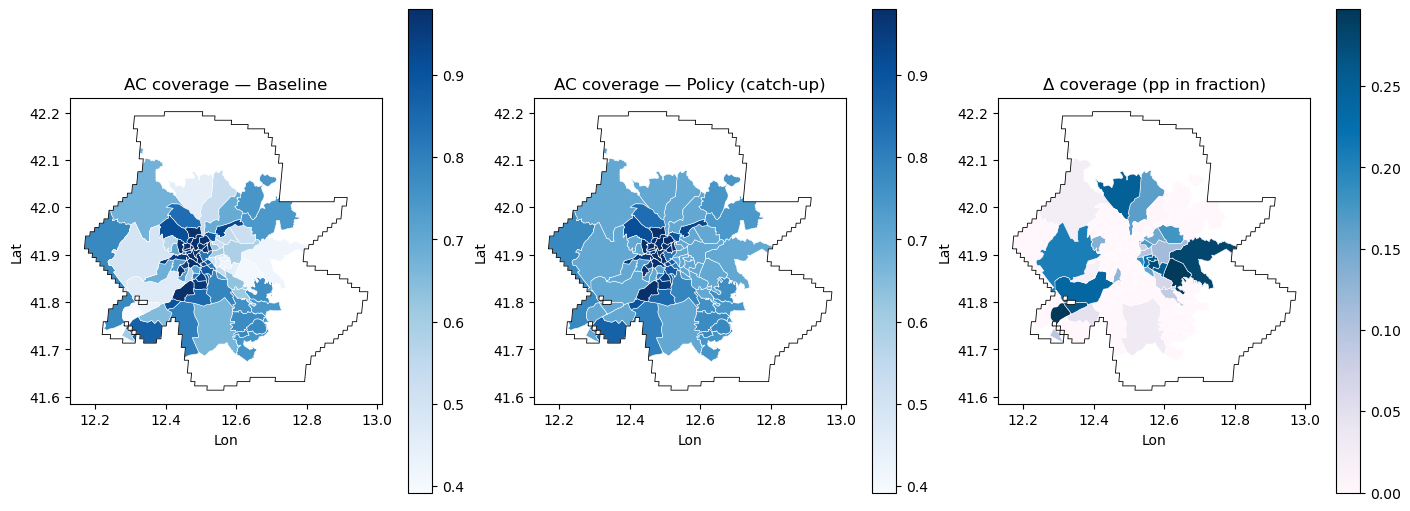

In [38]:
# maps: baseline, policy, delta (same plotting as before) 
cap_map = cap_4326.merge(cap_cov[[CAP_IDCOL,"ac_base","ac_policy","delta"]], on=CAP_IDCOL, how="left")

_min_base, _min_pol = cap_cov["ac_base"].min(), cap_cov["ac_policy"].min()
_max_base, _max_pol = cap_cov["ac_base"].max(), cap_cov["ac_policy"].max()
vmin = float(np.nanmin([_min_base, _min_pol])) if np.isfinite([_min_base, _min_pol]).any() else 0.0
vmax = float(np.nanmax([_max_base, _max_pol])) if np.isfinite([_max_base, _max_pol]).any() else 1.0
dv   = float(np.nanpercentile(np.abs(cap_map["delta"].to_numpy(dtype=float)), 99)) if "delta" in cap_map else 0.0
if not np.isfinite(dv) or dv == 0.0:
    dv = 0.0  # keeps plotting but avoids NaN ranges

fig, ax = plt.subplots(1,3, figsize=(14,5), constrained_layout=True)

_fua_wgs   = _to_wgs84(fua) if "fua" in globals() else None
_capmap_wgs= _to_wgs84(cap_map)

if _fua_wgs is not None: _fua_wgs.boundary.plot(ax=ax[0], color="k", lw=0.6)
_capmap_wgs.plot(ax=ax[0], column="ac_base", cmap="Blues",
                 vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True)
ax[0].set_title("AC coverage — Baseline"); ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

if _fua_wgs is not None: _fua_wgs.boundary.plot(ax=ax[1], color="k", lw=0.6)
_capmap_wgs.plot(ax=ax[1], column="ac_policy", cmap="Blues",
                 vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True)
ax[1].set_title("AC coverage — Policy (catch-up)"); ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

if _fua_wgs is not None: _fua_wgs.boundary.plot(ax=ax[2], color="k", lw=0.6)
_capmap_wgs.plot(ax=ax[2], column="delta", cmap="PuBu",
                 vmin=0.0, vmax=dv if dv > 0 else None,
                 edgecolor="white", lw=0.4, legend=True)
ax[2].set_title("Δ coverage (pp in fraction)"); ax[2].set_xlabel("Lon"); ax[2].set_ylabel("Lat")
plt.show()

In [41]:
# tables: top/bottom Δ by CAP 
tbl = (cap_cov.dropna(subset=["delta"])
              .assign(ac_base_pct=lambda d: 100*d["ac_base"],
                      ac_policy_pct=lambda d: 100*d["ac_policy"],
                      delta_pp=lambda d: 100*d["delta"])
              .sort_values(["delta_pp", CAP_CODE], ascending=[False, True]))
print("Top Δcoverage CAPs:")
top_tbl = tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]].head(10).reset_index(drop=True)
print(top_tbl if not _has_display else "")
if _has_display: display(top_tbl)
print("Bottom (or zero) Δcoverage CAPs:")
bot_tbl = (tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]]
           .tail(10).sort_values("delta_pp").reset_index(drop=True))
print(bot_tbl if not _has_display else "")
if _has_display: display(bot_tbl)

Top Δcoverage CAPs:
    cap5  ac_base_pct  ac_policy_pct  delta_pp     pop_cap
0  00119       39.185         70.000    30.815  17,485.161
1  00133       40.548         70.000    29.452 104,346.731
2  00132       41.848         70.000    28.152   9,058.825
3  00172       42.365         70.000    27.635  35,387.854
4  00126       43.220         70.000    26.780  37,270.786
5  00171       43.921         70.000    26.079  21,520.389
6  00169       44.601         70.000    25.399  34,904.343
7  00188       45.160         70.000    24.840  11,031.125
8  00148       46.176         70.000    23.824  71,563.741
9  00177       47.411         70.000    22.589  27,361.908
Bottom (or zero) Δcoverage CAPs:
    cap5  ac_base_pct  ac_policy_pct  delta_pp    pop_cap
0  00187       98.000         98.000     0.000 20,945.950
1  00189       83.763         83.763     0.000 33,387.494
2  00191       98.000         98.000     0.000 24,873.101
3  00192       98.000         98.000     0.000 10,480.892
4  00193

In [42]:
# some checks 
# sets at each stage
caps_csv   = set(inc_agg[CAP_CODE].astype(str))
caps_shp   = set(cap_4326[CAP_CODE].astype(str)) # after FUA clip
caps_rast  = set(cap_ref[CAP_CODE].astype(str))  # after reprojection (same as caps_shp)
ids_on_grid = set(np.unique(cap_on_ref[cap_on_ref > 0]).astype(int))
caps_labeled = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_on_grid), CAP_CODE].astype(str))

# CAPs with any pixel under CITY_MASK 
ids_cap_pix  = set(np.unique(cap_on_ref[CAP_PIX]).astype(int))
caps_cap_pix = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_cap_pix), CAP_CODE].astype(str))

# CAPs with >0 modeled pop in CAP_PIX
df_capgrid = pd.DataFrame({
    CAP_IDCOL: cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":     pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid[CAP_IDCOL] > 0]
pop_by_cap = (df_capgrid.groupby(CAP_IDCOL)["pop"].sum()
              .rename("pop_cap").reset_index())
caps_poppos = set(
    cap_ref.merge(pop_by_cap, on=CAP_IDCOL, how="left")
           .query("pop_cap > 0")[CAP_CODE].astype(str)
)

# buckets 
missing_in_shapes_or_outside_fua = sorted(caps_csv - caps_shp)
in_shapes_but_no_labeled_pixels  = sorted(caps_shp - caps_labeled)
labeled_but_not_in_CITY_MASK     = sorted(caps_labeled - caps_cap_pix)
in_CAP_PIX_but_zero_population   = sorted(caps_cap_pix - caps_poppos)

print("CSV CAPs:", len(caps_csv))
print("After FUA clip (polygons):", len(caps_shp))
print("Labeled on grid (any pixels):", len(caps_labeled))
print("In CAP_PIX (city mask & labeled):", len(caps_cap_pix))
print(">0 population in CAP_PIX:", len(caps_poppos))
print()
print("Missing (CSV but not in shapes/FUA):", len(missing_in_shapes_or_outside_fua), missing_in_shapes_or_outside_fua[:10])
print("No labeled pixels (resolution / all_touched=False):", len(in_shapes_but_no_labeled_pixels), in_shapes_but_no_labeled_pixels[:10])
print("Only outside CITY_MASK/hazard or pop==0 area:", len(labeled_but_not_in_CITY_MASK), labeled_but_not_in_CITY_MASK[:10])
print("Zero modeled pop in CAP_PIX:", len(in_CAP_PIX_but_zero_population), in_CAP_PIX_but_zero_population[:10])

CSV CAPs: 72
After FUA clip (polygons): 118
Labeled on grid (any pixels): 82
In CAP_PIX (city mask & labeled): 81
>0 population in CAP_PIX: 81

Missing (CSV but not in shapes/FUA): 0 []
No labeled pixels (resolution / all_touched=False): 36 ['00010', '00015', '00018', '00019', '00020', '00024', '00029', '00030', '00031', '00033']
Only outside CITY_MASK/hazard or pop==0 area: 1 ['00072']
Zero modeled pop in CAP_PIX: 0 []


Super important to understand why:
- In my income CSV there are 72 rows of 72 CAP with incomes data
- But then shapefile + FUA clip contains all CAP zones that intersect the FUA (metro area), not just the Comune di Roma → 118 CAPs. Many of those extra CAPs are the suburban/postal zones that start with 000xx (typical around Rome).
- After rasterization, 36 of those polygons don’t catch a grid cell at the resolution (all_touched=False) → “No labeled pixels”. One more has pixels but none in CITY_MASK (outside hazard or pop_on_ref==0)

**Municipi**

In [43]:
# City-agnostic config
REGION_GDF        = globals().get("regions", muni)   # GeoDataFrame of regions+outside
REGION_ID_FIELD   = "muni_id"                        # integer id per region
REGION_NAME_FIELD = "muni_name"                      # readable name
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"           # label when id==0 
PLOT_LABEL        = "Municipi"                       # for plot titles

[QA] City (grid) base=0.724 vs sum-over-Municipi=0.724
[QA] City (grid) pol =0.798 vs sum-over-Municipi=0.798

Top/bottom Municipi by Δ (policy - baseline), pp


,muni_id,muni_name,ac_base_pct,ac_policy_pct,delta_pp,pop_muni,users_base,users_policy
0,6,Municipio Roma VI,41.906,70.000,28.094,"130,848.193","54,833.077","91,593.733"
1,5,Municipio Roma V,50.584,70.191,19.607,"175,631.614","88,841.257","123,277.867"
2,11,Municipio Roma XI,54.984,70.865,15.882,"119,537.335","65,725.867","84,710.394"
3,4,Municipio Roma IV,58.146,71.122,12.976,"170,982.495","99,418.729","121,605.555"
4,13,Municipio Roma XIII,66.068,77.643,11.575,"131,022.061","86,563.858","101,729.748"
5,10,Municipio Roma X,67.283,76.125,8.843,"221,222.410","148,844.855","168,406.569"
6,14,Municipio Roma XIV,73.025,80.551,7.526,"158,029.184","115,400.355","127,293.299"
7,7,Municipio Roma VII,70.130,75.973,5.843,"248,257.701","174,103.522","188,609.955"
8,12,Municipio Roma XII,77.291,82.214,4.923,"131,970.543","102,001.277","108,498.577"
9,3,Municipio Roma III,74.945,77.992,3.047,"148,266.814","111,118.795","115,636.076"


,muni_id,muni_name,ac_base_pct,ac_policy_pct,delta_pp,pop_muni,users_base,users_policy
0,1,Municipio Roma I,94.973,94.973,0.000,"179,310.302","170,296.082","170,296.082"
1,2,Municipio Roma II,95.332,95.485,0.153,"161,208.331","153,683.726","153,929.950"
2,9,Municipio Roma IX,85.715,86.224,0.510,"219,039.174","187,748.522","188,865.416"
3,8,Municipio Roma VIII,83.735,84.837,1.102,"113,726.641","95,229.345","96,482.737"
4,15,Municipio Roma XV,84.390,87.268,2.878,"98,417.632","83,054.529","85,887.180"
5,3,Municipio Roma III,74.945,77.992,3.047,"148,266.814","111,118.795","115,636.076"
6,12,Municipio Roma XII,77.291,82.214,4.923,"131,970.543","102,001.277","108,498.577"
7,7,Municipio Roma VII,70.130,75.973,5.843,"248,257.701","174,103.522","188,609.955"
8,14,Municipio Roma XIV,73.025,80.551,7.526,"158,029.184","115,400.355","127,293.299"
9,10,Municipio Roma X,67.283,76.125,8.843,"221,222.410","148,844.855","168,406.569"


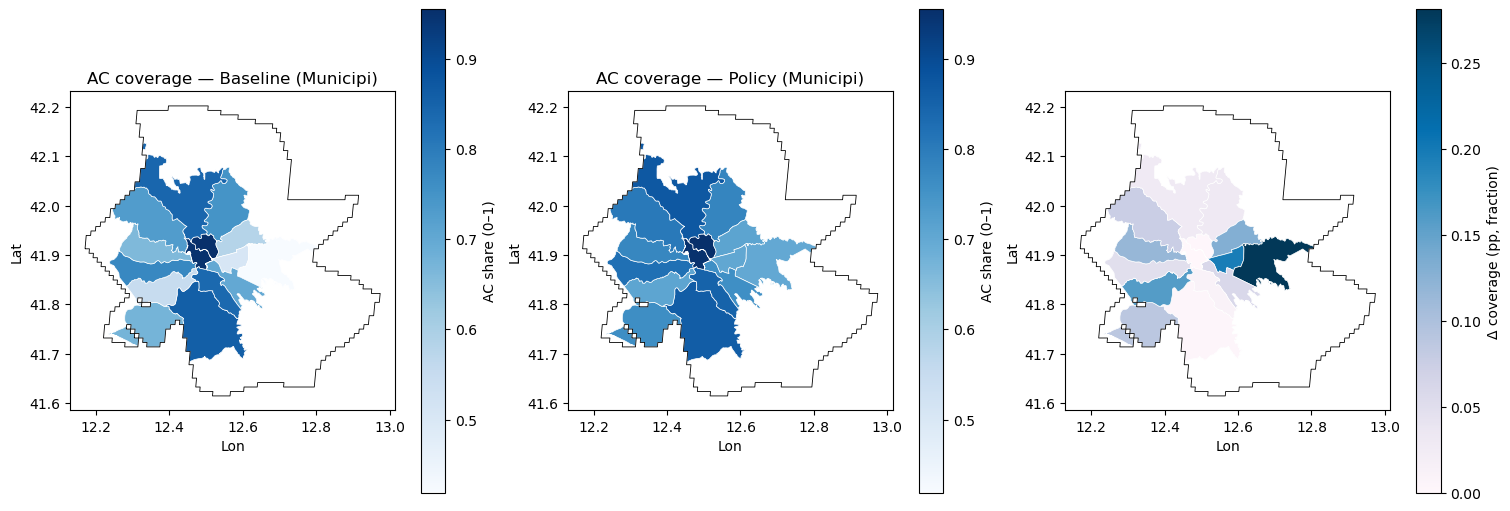

In [45]:
# Municipio level AC COVERAGE: baseline & policy (pop-weighted)

import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import rasterize

# municipio label raster on the CLIMADA grid
if "muni_on_ref" not in globals():
    regions_ref = REGION_GDF.to_crs(ref_meta["crs"])
    shapes = [(geom, int(rid)) for geom, rid in zip(regions_ref.geometry, regions_ref[REGION_ID_FIELD])]
    muni_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=-1, dtype="int32", all_touched=False
    )

# pop-weighted aggregation of AC baseline/policy to Municipi
# using the CAP universe where coverage
mask = CAP_MASK & (muni_on_ref >= 0)
df = pd.DataFrame({
    "region_id": muni_on_ref[mask].ravel().astype(int),   # includes 0 = outside bucket if present
    "pop":       pop_on_ref[mask].ravel().astype(float),
    "base":      coverage_base[mask].ravel().astype(float),
    "policy":    coverage_policy[mask].ravel().astype(float),
})

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

muni_cov = (df.groupby("region_id")
              .apply(lambda g: pd.Series({
                  "ac_base":   _wavg(g["base"],   g["pop"]),
                  "ac_policy": _wavg(g["policy"], g["pop"]),
                  "pop_muni":  float(g["pop"].sum())
              }))
              .reset_index())

muni_cov = (muni_cov
            .rename(columns={"region_id":"muni_id",
                             "ac_base":"ac_base_muni",
                             "ac_policy":"ac_policy_muni"})
            .assign(delta=lambda d: d["ac_policy_muni"] - d["ac_base_muni"],
                    delta_pp=lambda d: 100*(d["ac_policy_muni"] - d["ac_base_muni"])))

# users (unchanged)
dfm = df.copy()
dfm = dfm.rename(columns={"region_id":"muni_id"})
dfm["users_base"]   = dfm["base"]   * dfm["pop"]
dfm["users_policy"] = dfm["policy"] * dfm["pop"]

muni_pop   = dfm.groupby("muni_id", as_index=False)["pop"].sum().rename(columns={"pop":"pop_muni"})
muni_users = (dfm.groupby("muni_id", as_index=False)
                .agg(users_base=("users_base","sum"),
                     users_policy=("users_policy","sum")))

# attaching names and keeping a readable name for id==0
name_cols = REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD]].rename(
    columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"}
)

muni_cov = (muni_cov
            .merge(muni_users, on="muni_id", how="left")
            .merge(name_cols,  on="muni_id", how="left"))

muni_cov["muni_name"] = muni_cov["muni_name"].fillna(OUTSIDE_LABEL)

# check
city_base  = popw_mean(coverage_base,   CAP_MASK)
city_pol   = popw_mean(coverage_policy, CAP_MASK)
agg_base   = float(np.nansum(muni_cov["ac_base_muni"]   * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
agg_policy = float(np.nansum(muni_cov["ac_policy_muni"] * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
print(f"[QA] City (grid) base={city_base:.3f} vs sum-over-Municipi={agg_base:.3f}")
print(f"[QA] City (grid) pol ={city_pol:.3f} vs sum-over-Municipi={agg_policy:.3f}")

# tables
muni_only = muni_cov[muni_cov["muni_id"] > 0].copy()
muni_only["ac_base_pct"]   = 100*muni_only["ac_base_muni"]
muni_only["ac_policy_pct"] = 100*muni_only["ac_policy_muni"]
muni_only["delta_pp"]      = 100*muni_only["delta"]

print("\nTop/bottom Municipi by Δ (policy - baseline), pp")
top = muni_only.sort_values("delta_pp", ascending=False).head(10)
bot = muni_only.sort_values("delta_pp", ascending=True).head(10)
display(top[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp","pop_muni","users_base","users_policy"]].reset_index(drop=True))
display(bot[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp","pop_muni","users_base","users_policy"]].reset_index(drop=True))

# maps 
muni_map = (REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD, "geometry"]]
            .rename(columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"})
            .merge(muni_only, on="muni_id", how="left"))

vmin = float(np.nanmin(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
vmax = float(np.nanmax(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))

fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)

fua.to_crs("EPSG:4326").boundary.plot(ax=ax[0], color="k", lw=0.6)
muni_map.to_crs("EPSG:4326").plot(
    ax=ax[0], column="ac_base_muni", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
    legend_kwds={"label":"AC share (0–1)"}
)
ax[0].set_title(f"AC coverage — Baseline ({PLOT_LABEL})")

fua.to_crs("EPSG:4326").boundary.plot(ax=ax[1], color="k", lw=0.6)
muni_map.to_crs("EPSG:4326").plot(
    ax=ax[1], column="ac_policy_muni", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
    legend_kwds={"label":"AC share (0–1)"}
)
ax[1].set_title(f"AC coverage — Policy ({PLOT_LABEL})")

dv = float(np.nanmax(np.abs(muni_map["delta"])))
fua.to_crs("EPSG:4326").boundary.plot(ax=ax[2], color="k", lw=0.6)
muni_map.to_crs("EPSG:4326").plot(
    ax=ax[2], column="delta", cmap="PuBu",
    vmin=0.0, vmax=dv, edgecolor="white", lw=0.5, legend=True,
    legend_kwds={"label":"Δ coverage (pp, fraction)"}
)
for a in ax: a.set_xlabel("Lon"); a.set_ylabel("Lat")
plt.show()

**Mortality with AC: uniform efficacy vs age-varying efficacy**

In [46]:
EFF_MAP = (cfg.get("efficacy", {}) if "cfg" in globals() else {})  
EFF_DEFAULT = float(EFF_MAP.get("default", 0.30))
ANCHOR_YEAR = int(cfg.get("impact_functions", {}).get("anchor_event", 2050)) if "cfg" in globals() else 2050

In [47]:
REGION_GDF        = globals().get("regions", muni)   
REGION_ID_FIELD   = "muni_id"
REGION_NAME_FIELD = "muni_name"
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"

In [48]:
# prep coverage rasters for mortality 
# using same city universe as before
mask_city = CITY_MASK

# baseline city mean on the CAP universe
ac_city = float(popw_mean(coverage_base, CAP_MASK))

In [49]:
def _interp_mdd(I_grid, f):
    return np.interp(I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def deaths_with_ac(I_grid, coverage_grid, eff=0.30):
    """Uniform efficacy: MDD_adj = MDD * (1 - eff * coverage)."""
    m = mask_city & np.isfinite(I_grid)
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city)
    deaths = np.zeros_like(I_grid, dtype=float)
    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        mult = np.clip(1.0 - eff * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def _eff_for_age(age_lbl, eff_map, eff_default):
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default": 
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)

def deaths_with_ac_varage(I_grid, coverage_grid, eff_by_bucket=None, eff_base=None):
    eff_map = (eff_by_bucket or EFF_MAP).copy()
    eff_def = EFF_DEFAULT if eff_base is None else float(eff_base)

    m = mask_city & np.isfinite(I_grid)
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city)
    deaths = np.zeros_like(I_grid, dtype=float)

    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        eff_a = _eff_for_age(age_lbl, eff_map, eff_def)
        mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

In [50]:
# event pulled from YAML (2050 as default) 
year_focus = ANCHOR_YEAR
i_ev = list(H.event_id).index(year_focus)
I_anchor = _row_to_grid(H.intensity, i_ev, ref_data.shape)

In [51]:
# Deaths: baseline vs policy (uniform and age-varying)
EFF_UNIFORM  = EFF_DEFAULT  
EFF_BUCKETS  = EFF_MAP      

deaths_base_uni   = deaths_with_ac(I_anchor, coverage_base,   eff=EFF_UNIFORM)
deaths_policy_uni = deaths_with_ac(I_anchor, coverage_policy, eff=EFF_UNIFORM)

deaths_base_age   = deaths_with_ac_varage(I_anchor, coverage_base,   eff_by_bucket=EFF_BUCKETS)
deaths_policy_age = deaths_with_ac_varage(I_anchor, coverage_policy, eff_by_bucket=EFF_BUCKETS)

In [52]:
# City totals (unchanged) 
d_avo_uni = deaths_base_uni - deaths_policy_uni
d_avo_age = deaths_base_age - deaths_policy_age
city_total_avo_uni = float(np.nansum(d_avo_uni[mask_city]))
city_total_avo_age = float(np.nansum(d_avo_age[mask_city]))

In [53]:
# Region aggregation
if "muni_on_ref" not in globals():
    regions_ref = REGION_GDF.to_crs(ref_meta["crs"])
    shapes = [(geom, int(rid)) for geom, rid in zip(regions_ref.geometry, regions_ref[REGION_ID_FIELD])]
    muni_on_ref = rasterize(
        shapes=shapes, out_shape=ref_data.shape, transform=ref_meta["transform"],
        fill=-1, dtype="int32", all_touched=False
    )

_id2name = dict(zip(REGION_GDF[REGION_ID_FIELD], REGION_GDF[REGION_NAME_FIELD]))
_id2name[0] = OUTSIDE_LABEL

def muni_agg_avoided(d_avo_grid):
    rows = []
    ids = np.unique(muni_on_ref[np.isfinite(ref_data) & (muni_on_ref >= 0)]).astype(int)
    for mid in ids:
        m = (muni_on_ref == mid) & mask_city
        if not np.any(m): 
            continue
        pop_m = float(sum(np.nansum(np.nan_to_num(age_on_ref[a], 0.0)[m]) for a in age_ifs))
        d_avo_m = float(np.nansum(d_avo_grid[m]))
        rows.append({"muni_id": mid, "muni_name": _id2name.get(mid, str(mid)),
                     "avoided": d_avo_m,
                     "avo_per_100k": (d_avo_m/pop_m*1e5) if pop_m>0 else np.nan})
    return pd.DataFrame(rows)

df_muni_avo_uni = muni_agg_avoided(d_avo_uni)
df_muni_avo_age = muni_agg_avoided(d_avo_age)

print("Sum of municipio avoided vs city total — uniform:",
      df_muni_avo_uni["avoided"].sum(), city_total_avo_uni)
print("Sum of municipio avoided vs city total — age-varying:",
      df_muni_avo_age["avoided"].sum(), city_total_avo_age)

Sum of municipio avoided vs city total — uniform: 58.52306789098362 58.523067890983626
Sum of municipio avoided vs city total — age-varying: 76.72763364788005 76.72763364788005


In [54]:
# change in coverage per region
df = pd.DataFrame({
    "muni_id":  muni_on_ref[CAP_MASK].ravel().astype(int),
    "pop":      pop_on_ref[CAP_MASK].ravel().astype(float),
    "base":     coverage_base[CAP_MASK].ravel().astype(float),
    "policy":   coverage_policy[CAP_MASK].ravel().astype(float),
})
df_muni_delta = (
    df.assign(delta=df["policy"] - df["base"])
      .groupby("muni_id", as_index=False)
      .apply(lambda g: pd.Series({
          "ΔAC_pw":       float(np.average(g["delta"], weights=g["pop"])) if g["pop"].sum() > 0 else np.nan,
          "pop_cap_mask": float(g["pop"].sum()),
      }))
      .reset_index(drop=True)
)
df_muni_delta["muni_name"] = df_muni_delta["muni_id"].map(_id2name)

city_dpp_from_muni = 100.0 * (
    (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_cap_mask"]).sum()
    / df_muni_delta["pop_cap_mask"].sum()
)
city_dpp_from_map = 100.0 * popw_mean(coverage_policy - coverage_base, mask=CAP_MASK)
print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)

City ΔAC (pp) from municipios vs map: 7.454453034255105 7.454453034255105


In [55]:
# joining avoided deaths to change in AC and rank 
MIN_PP = 0.5
muni_eff_uni = (df_muni_avo_uni.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                            .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                    avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                    flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))
muni_eff_age = (df_muni_avo_age.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                            .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                    avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                    flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

print("Top municipios (avoided per pp uplift) — uniform EFF:")
display(muni_eff_uni.sort_values("avoided_per_pp", ascending=False)
        [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
        .head(10).reset_index(drop=True))

print("Top municipios (avoided per pp uplift) — age-varying EFF:")
display(muni_eff_age.sort_values("avoided_per_pp", ascending=False)
        [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
        .head(10).reset_index(drop=True))

Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,2,Municipio Roma II,0.134,0.083,0.153,0.876
1,7,Municipio Roma VII,4.188,1.687,5.843,0.717
2,9,Municipio Roma IX,0.344,0.157,0.510,0.674
3,10,Municipio Roma X,5.791,2.618,8.843,0.655
4,5,Municipio Roma V,12.506,7.120,19.607,0.638
5,4,Municipio Roma IV,7.130,4.170,12.976,0.549
6,3,Municipio Roma III,1.538,1.038,3.047,0.505
7,6,Municipio Roma VI,11.768,8.994,28.094,0.419
8,11,Municipio Roma XI,6.101,5.104,15.882,0.384
9,12,Municipio Roma XII,1.877,1.422,4.923,0.381


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,2,Municipio Roma II,0.176,0.109,0.153,1.150
1,7,Municipio Roma VII,5.490,2.212,5.843,0.940
2,9,Municipio Roma IX,0.451,0.206,0.510,0.884
3,10,Municipio Roma X,7.591,3.431,8.843,0.858
4,5,Municipio Roma V,16.401,9.338,19.607,0.836
5,4,Municipio Roma IV,9.350,5.468,12.976,0.721
6,3,Municipio Roma III,2.018,1.361,3.047,0.662
7,6,Municipio Roma VI,15.429,11.792,28.094,0.549
8,11,Municipio Roma XI,8.000,6.692,15.882,0.504
9,12,Municipio Roma XII,2.460,1.864,4.923,0.500


In [56]:
# final consistency prints
city_dpp_from_muni = 100 * float(
    (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_cap_mask"]).sum()
    / df_muni_delta["pop_cap_mask"].sum()
)
city_dpp_from_map = 100 * popw_mean(coverage_policy - coverage_base, mask=CAP_MASK)
print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)
print("Sum of municipio avoided vs city total — uniform:",
      df_muni_avo_uni["avoided"].sum(), city_total_avo_uni)
print("Sum of municipio avoided vs city total — age-varying:",
      df_muni_avo_age["avoided"].sum(), city_total_avo_age)

City ΔAC (pp) from municipios vs map: 7.454453034255105 7.454453034255105
Sum of municipio avoided vs city total — uniform: 58.52306789098362 58.523067890983626
Sum of municipio avoided vs city total — age-varying: 76.72763364788005 76.72763364788005


More **avoided deaths** with the age-varying efficacy

**Shift in IF**

In [58]:
def _age_keys_from_cfg(age_ifs, cfg):
    try:
        declared = list(cfg["impact_functions"]["age_params"].keys())
        return [k for k in declared if k in age_ifs] + [k for k in age_ifs if k not in declared]
    except Exception:
        return list(age_ifs.keys())

age_keys = _age_keys_from_cfg(age_ifs, cfg)

EFFS = dict(cfg.get("efficacy", {}))
EFF_UNIFORM = float(EFFS.get("default", 0.30))
EFF_BUCKETS = {k: float(v) for k, v in EFFS.items() if k != "default"}
EFF_BUCKETS = {k: EFF_BUCKETS.get(k, EFF_UNIFORM) for k in age_keys}

In [59]:
# pop-weighted helper over analysis domain (CAP_MASK so coverage defined) 
DOM_MASK = CAP_MASK & np.isfinite(pop_on_ref)
w = np.where(DOM_MASK, pop_on_ref, 0.0)

def wavg_multiplier(coverage, eff):
    mult = np.clip(1.0 - eff * np.where(DOM_MASK, coverage, 0.0), 0.0, 1.0)
    return float(np.nansum(mult * w) / np.nansum(w)) if np.nansum(w) > 0 else np.nan

[Uniform eff=0.30] pop-w multiplier: baseline=0.783, policy=0.761, policy/base=0.971


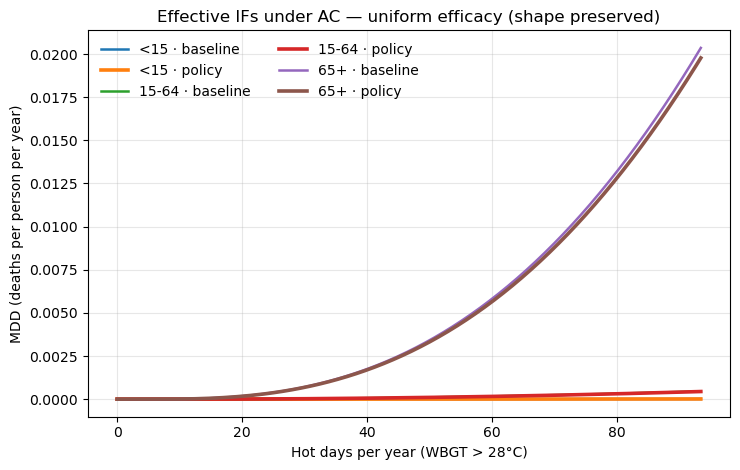

In [60]:
# uniform efficacy shift 
m_base_uni   = wavg_multiplier(coverage_base,   EFF_UNIFORM)
m_policy_uni = wavg_multiplier(coverage_policy, EFF_UNIFORM)

print(f"[Uniform eff={EFF_UNIFORM:.2f}] pop-w multiplier: "
      f"baseline={m_base_uni:.3f}, policy={m_policy_uni:.3f}, "
      f"policy/base={m_policy_uni/m_base_uni:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)
    y_base   = y0 * m_base_uni
    y_policy = y0 * m_policy_uni
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Hot days per year (WBGT > 28°C)")
plt.ylabel("MDD (deaths per person per year)")
plt.title("Effective IFs under AC — uniform efficacy (shape preserved)")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

[Age-varying eff] pop-w multipliers:
    <15: baseline=0.855, policy=0.840, policy/base=0.983
  15-64: baseline=0.783, policy=0.761, policy/base=0.971
    65+: baseline=0.711, policy=0.681, policy/base=0.958


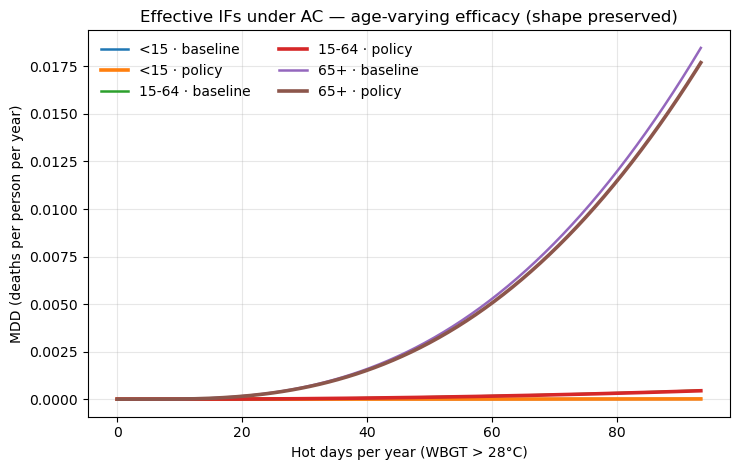

In [61]:
# age-varying efficacy shift 
m_base_age   = {age: wavg_multiplier(coverage_base,   EFF_BUCKETS[age]) for age in age_keys}
m_policy_age = {age: wavg_multiplier(coverage_policy, EFF_BUCKETS[age]) for age in age_keys}

print("[Age-varying eff] pop-w multipliers:")
for age in age_keys:
    mb, mp = m_base_age[age], m_policy_age[age]
    print(f"  {age:>5}: baseline={mb:.3f}, policy={mp:.3f}, policy/base={mp/mb:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)
    y_base   = y0 * m_base_age[k]
    y_policy = y0 * m_policy_age[k]
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Hot days per year (WBGT > 28°C)")
plt.ylabel("MDD (deaths per person per year)")
plt.title("Effective IFs under AC — age-varying efficacy (shape preserved)")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

Conversely to before and to the CLIMADA method, here scaling is continuous, pixel by pixel => we don't create bins and discretise the cap specific scalings into a few categories => for pixel p in CAP c and age a : we multiply the impact function for the age a x by (1- efficacy of a * coverage of p) => we have one IF per CAP*age but we don't instantiate thousands of separate IF objects => we multiply by the local factor inside deaths_with_ac(...). 

> **Notes:**
> - In the uniform efficacy, all ages are scaled down by the same proportion but it looks like only 65 + moves because the 65+ IF is much larger so the % shrink is more obvious visually. 
> - In the second case - age-varying efficacy - the scale down is stronger but especially because of the fact that the efficacy for the 65+ is stronger than the uniform efficacy
> - Careful: the scaling looks small because it's the INCREMENTAL change: baseline (current AC) vs post-policy

**Saving for later**

In [62]:
from pathlib import Path
import json
import numpy as np
import rasterio as rio
import geopandas as gpd

SLUG = cfg.get("slug", CITY.lower()) 
OUT = Path(OUT); INT = Path(INT)
OUT.mkdir(parents=True, exist_ok=True)
INT.mkdir(parents=True, exist_ok=True)

In [63]:
# Save AC coverage for later
npz_path_slug = INT / f"ac_coverage_maps_{SLUG}.npz"
npz_path_legacy = INT / "ac_coverage_maps.npz"  

payload = dict(
    coverage_base   = coverage_base.astype("float32"),
    coverage_policy = coverage_policy.astype("float32"),
    CAP_MASK        = CAP_MASK.astype("uint8"),
    CITY_MASK       = CITY_MASK.astype("uint8"),
    HGT             = np.int32(HGT),
    WDT             = np.int32(WDT),
)

np.savez_compressed(npz_path_slug, **payload)
np.savez_compressed(npz_path_legacy, **payload)

# or Geotiffs
meta = ref_meta.copy()
meta.update({"dtype": "float32", "count": 1, "nodata": np.float32(np.nan)})
with rio.open(INT / f"ac_coverage_base_{SLUG}.tif", "w", **meta) as dst:
    dst.write(coverage_base.astype("float32"), 1)
with rio.open(INT / f"ac_coverage_policy_{SLUG}.tif", "w", **meta) as dst:
    dst.write(coverage_policy.astype("float32"), 1)

print("Wrote:", npz_path_slug, "and legacy", npz_path_legacy)
print("Wrote:", INT / f"ac_coverage_base_{SLUG}.tif", INT / f"ac_coverage_policy_{SLUG}.tif")

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_maps_rome.npz and legacy /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_maps.npz
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_base_rome.tif /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_policy_rome.tif


In [64]:
# saving cap_on_ref 
np.savez_compressed(INT / f"cap_on_ref_{SLUG}.npz", cap_on_ref=cap_on_ref.astype("int32"))
# also as GeoTIFF aligned to the WBGT ref grid
meta_cap = ref_meta.copy()
meta_cap.update({"dtype": "int32", "count": 1, "nodata": 0})
with rio.open(INT / f"cap_on_ref_{SLUG}.tif", "w", **meta_cap) as dst:
    dst.write(cap_on_ref.astype("int32"), 1)
print("Wrote:", INT / f"cap_on_ref_{SLUG}.npz", INT / f"cap_on_ref_{SLUG}.tif")

# LUT: cap_id <-> cap5 used in this notebook
(cap_ref[["cap_id","cap5"]]
 .astype({"cap_id": int, "cap5": str})
 .drop_duplicates()
 .to_csv(OUT / f"{SLUG}_cap_lut.csv", index=False))

gpkg_cap = OUT / f"{SLUG}_cap.gpkg"
cap_ref.to_file(gpkg_cap, layer="cap", driver="GPKG")

# WGS84 versions + lookups
cap_4326 = cap_4326.set_crs("EPSG:4326", allow_override=True)
cap_4326.to_file(gpkg_cap, layer="cap_wgs84", driver="GPKG")
cap_4326.to_file(OUT / f"{SLUG}_cap_wgs84.geojson", driver="GeoJSON")
(cap_4326[["cap_id","cap5"]].astype({"cap_id": int, "cap5": str})
         .drop_duplicates()
         .to_csv(OUT / f"{SLUG}_cap_wgs84_lut.csv", index=False))

print("Wrote:", OUT / f"{SLUG}_cap_lut.csv")
print("Wrote:", gpkg_cap, "(layers: 'cap', 'cap_wgs84')")
print("Wrote:", OUT / f"{SLUG}_cap_wgs84.geojson", OUT / f"{SLUG}_cap_wgs84_lut.csv")

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/cap_on_ref_rome.npz /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/cap_on_ref_rome.tif
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_lut.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap.gpkg (layers: 'cap', 'cap_wgs84')
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_wgs84.geojson /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_wgs84_lut.csv


In [65]:
# saving AC efficacy by age 
eff_path = INT / f"ac_eff_buckets_{SLUG}.json"
try:
    EFF_BUCKETS  
except NameError:
    EFFS = dict(cfg.get("efficacy", {}))
    default_eff = float(EFFS.get("default", 0.30))
    EFF_BUCKETS = {k: float(v) for k, v in EFFS.items() if k != "default"}
    # Ensure entries for all ages in age_ifs
    for k in age_ifs.keys():
        EFF_BUCKETS.setdefault(k, default_eff)

with open(eff_path, "w") as fh:
    json.dump(EFF_BUCKETS, fh)
print("Wrote:", eff_path)

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_eff_buckets_rome.json


In [66]:
# AC coverage (municipio means) 
muni_on_ref_path = OUT / f"muni_on_ref_{SLUG}.tif"
if not muni_on_ref_path.exists():
    legacy = OUT / "muni_on_ref.tif"
    assert legacy.exists(), f"Missing {muni_on_ref_path} (or legacy muni_on_ref.tif). Save it in NB5."
    muni_on_ref_path = legacy

with rio.open(muni_on_ref_path) as src:
    muni_on_ref = src.read(1).astype(np.int32)

# optional names
muni_names = None
try:
    muni_gpkg = OUT / f"{SLUG}_regions.gpkg"
    if muni_gpkg.exists():
        muni_gdf = gpd.read_file(muni_gpkg, layer="muni")
        muni_names = muni_gdf[['muni_id','muni_name']].drop_duplicates()
except Exception:
    pass

valid = (np.isfinite(pop_on_ref)
         & np.isfinite(coverage_base) & np.isfinite(coverage_policy)
         & (muni_on_ref > 0))

df = pd.DataFrame({
    'muni_id':  muni_on_ref[valid].ravel().astype(int),
    'pop':      pop_on_ref[valid].ravel().astype(float),
    'users_b': (coverage_base[valid]  * pop_on_ref[valid]).ravel().astype(float),
    'users_p': (coverage_policy[valid]* pop_on_ref[valid]).ravel().astype(float),
})

grp = (df.groupby('muni_id', as_index=False)
         .agg(pop_muni=('pop','sum'),
              users_b=('users_b','sum'),
              users_p=('users_p','sum')))

muni_cov = grp.assign(
    ac_base_muni   = lambda d: np.where(d['pop_muni']>0, d['users_b']/d['pop_muni'], np.nan),
    ac_policy_muni = lambda d: np.where(d['pop_muni']>0, d['users_p']/d['pop_muni'], np.nan)
)[['muni_id','pop_muni','ac_base_muni','ac_policy_muni']]

if muni_names is not None:
    muni_cov = (muni_cov.merge(muni_names, on='muni_id', how='left')
                        [['muni_id','muni_name','pop_muni','ac_base_muni','ac_policy_muni']])

muni_cov.to_csv(OUT / f"muni_cov_{SLUG}.csv", index=False)
print("Wrote:", OUT / f"muni_cov_{SLUG}.csv")

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/muni_cov_rome.csv


In [70]:
SLUG = cfg.get("slug", CITY.lower())

np.savez_compressed(
    INT / f"ac_coverage_maps_{SLUG}.npz",
    coverage_base   = coverage_base.astype("float32"),
    coverage_policy = coverage_policy.astype("float32"),
    CAP_MASK        = CAP_MASK.astype("uint8"),   
    CITY_MASK       = CITY_MASK.astype("uint8"),
    HGT             = np.int32(HGT),
    WDT             = np.int32(WDT),
)
print("✓ Wrote", INT / f"ac_coverage_maps_{SLUG}.npz")

✓ Wrote /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_maps_rome.npz


In [72]:
# municipio ids on ref grid
with rio.open(OUT / f"muni_on_ref_{SLUG}.tif", "w", **{**ref_meta, "dtype":"int32","count":1,"nodata":0} ) as dst:
    dst.write(muni_on_ref.astype("int32"), 1)